# Results

This notebook collects the main empirical exhibits used in the writeup. All data construction, proxy analysis, model estimation, and forecast evaluation were completed in the preceding notebooks; the purpose here is only to present those results in a compact, self-contained form.

The exhibits proceed from measurement to forecasting. I first establish the sampling choice and compare the volatility proxies, then evaluate the forecasting models, and finally isolate the effect of changing the evaluation proxy from the effect of refitting the forecasting model.

## 1. Choosing the realized-variance sampling frequency

How finely should intraday prices be sampled when constructing realized variance? Sampling too frequently increases sensitivity to market microstructure effects and stale prices, while sampling too slowly discards useful intraday information.

The volatility signature plot shows how estimated realized variance changes with sampling frequency, while the right figure shows the corresponding deterioration in price freshness (Blue line) as well as the effects of discretization (Orange line). Together, these diagnostics motivate the sampling frequency used for realized variance throughout the rest of the analysis.

![Volatility signature plot and staleness](../figures/signature_staleness.png)

By 30 seconds, 99.1% of bins contain at least one trade, so arrival staleness is effectively resolved. What remains is discretization: 16.6% of 30-second bars print at the previous bar's price, because a one-cent tick on a $28 stock is 3.5bp and the efficient price frequently moves less than that. This is a property of the tick grid rather than the sampling grid, and it does not fall away with coarser sampling as 2.0% of 30-minute bars are still unchanged. Since it cannot be sampled around, it is a floor rather than a constraint on Δ, and the binding constraint on how fine we can go is arrival staleness, which 30s resolves.

## 2. How different are the volatility proxies?

The forecasting exercise is evaluated against three observable volatility proxies: realized variance, the Garman–Klass range estimator, and squared close-to-close returns. Before comparing forecast performance, it is useful to establish how similarly these measures behave in the underlying data.

The left panel compares their smoothed time-series behavior, while the right panel plots the alternative proxies against realized variance on logarithmic axes. The 45-degree line indicates exact agreement with realized variance.

![Volatility signature plot and staleness](../figures/proxies.png)

Realized variance and the Garman–Klass estimator track one another closely, although the range estimator tends to be slightly lower on a typical day. Close-to-close squared returns are substantially noisier and display much greater dispersion around realized variance.

The distinction matters for forecast evaluation: changing the proxy can alter the observed loss even when the underlying forecast itself is held fixed. The later fixed-forecast experiment separates this measurement effect from changes caused by model refitting.

## 3. Out-of-sample volatility forecasts

How closely do the competing forecasting models track realized volatility out of sample? The figure compares observed realized variance with the HAR and GARCH forecasts over the 2025 out-of-sample period.

The purpose is descriptive rather than a formal ranking exercise. It shows where the models respond similarly, where their forecasts diverge, and how both behave around the largest volatility episodes of the year.

![Volatility signature plot and staleness](../figures/forecasts.png)

From visual insepction alone, we see some notable differences between the two forecasting models. HAR appears to be more smoothed and produces less volatility spikes that GARCH. From an initial glance, we see that GARCH seems to produce a graph more similar the actual (Realized Volatility). But this is not sufficient to rank or evaluate the mdoels. We need to determine how delayed the peaks are, see where each model overshoots and undershoots, and grade them accordingly.

The formal comparison therefore uses QLIKE loss. The next table reports mean out-of-sample loss for all three models and all three evaluation proxies.

## 4. Forecast performance under matched proxies

The first comparison uses a matched-proxy design: for each volatility proxy, a model is fit on that proxy (the estimation proxy) and scored against the same proxy out of sample (the evaluation proxy). GARCH is the exception and is fit on daily close-to-close log returns, so a single GARCH forecast series is graded against all three proxies.

Each row below reports mean QLIKE for the model in each column, graded against the proxy named at the start of the row. The Range (GK) row's HAR entry of −5.312, for instance, is a HAR model fit on Garman–Klass and scored against Garman–Klass. Because each row uses a different set of "correct" answers, mean losses are comparable within a row but not across rows.

Note that this design moves two things at once: crossing rows changes both the series the model learned from and the series it is graded against. Sections 5 and 6 separate them

In [15]:
import pandas as pd
from IPython.display import display, Markdown

primary = pd.read_csv("../results/mean_loss_primary.csv", index_col=0)
primary_diffs = pd.read_csv("../results/diffs_primary.csv")

no_earnings = pd.read_csv("../results/mean_loss_no_earnings.csv", index_col=0)
no_earnings_diffs = pd.read_csv("../results/diffs_no_earnings.csv")

display(Markdown("### Panel A — All out-of-sample days"))
display(primary)

display(Markdown("**Pairwise differences — negative means the first model has lower QLIKE.**"))
display(primary_diffs)

display(Markdown("### Panel B — Earnings days excluded"))
display(no_earnings)

display(Markdown("**Pairwise differences — negative means the first model has lower QLIKE.**"))
display(no_earnings_diffs)

### Panel A — All out-of-sample days

,NAIVE,HAR,GARCH,Best
Realized variance,-5.264882,-5.409395,-5.332385,HAR
Range (GK),-4.875465,-5.312212,-5.305086,HAR
Close-to-close,96.674332,-5.416647,-5.348735,HAR


**Pairwise differences — negative means the first model has lower QLIKE.**

,Proxy,Comparison,Δ loss,NW s.e.,t,sig
0,Realized variance,HAR − NAIVE,-0.144514,0.044832,-3.223458,*
1,Realized variance,HAR − GARCH,-0.077010,0.051026,-1.509227,NaN
2,Realized variance,GARCH − NAIVE,-0.067503,0.074814,-0.902280,NaN
3,Range (GK),HAR − NAIVE,-0.436747,0.101835,-4.288755,*
4,Range (GK),HAR − GARCH,-0.007126,0.080828,-0.088157,NaN
5,Range (GK),GARCH − NAIVE,-0.429622,0.159834,-2.687924,*
6,Close-to-close,HAR − NAIVE,-102.090978,39.430562,-2.589133,*
7,Close-to-close,HAR − GARCH,-0.067911,0.208523,-0.325678,NaN
8,Close-to-close,GARCH − NAIVE,-102.023067,39.435416,-2.587092,*


### Panel B — Earnings days excluded

,NAIVE,HAR,GARCH,Best
Realized variance,-5.369549,-5.488586,-5.379118,HAR
Range (GK),-5.006061,-5.384997,-5.347971,HAR
Close-to-close,98.310411,-5.433804,-5.368351,HAR


**Pairwise differences — negative means the first model has lower QLIKE.**

,Proxy,Comparison,Δ loss,NW s.e.,t,sig
0,Realized variance,HAR − NAIVE,-0.119037,0.042061,-2.830083,*
1,Realized variance,HAR − GARCH,-0.109468,0.045656,-2.397659,*
2,Realized variance,GARCH − NAIVE,-0.009569,0.064972,-0.147281,NaN
3,Range (GK),HAR − NAIVE,-0.378935,0.094104,-4.026761,*
4,Range (GK),HAR − GARCH,-0.037026,0.078645,-0.470792,NaN
5,Range (GK),GARCH − NAIVE,-0.341910,0.148356,-2.304663,*
6,Close-to-close,HAR − NAIVE,-103.744215,40.072843,-2.588891,*
7,Close-to-close,HAR − GARCH,-0.065453,0.212054,-0.308661,NaN
8,Close-to-close,GARCH − NAIVE,-103.678762,40.077634,-2.586948,*


HAR has the lowest mean QLIKE in every row, and beats naive persistence significantly under all three proxies (t = −3.22, −4.29, −2.59). Its advantage over GARCH is not statistically distinguishable from zero anywhere in the primary panel, and the size of that advantage varies sharply across rows: −0.077 under realized variance, −0.007 under Garman–Klass, −0.068 under close-to-close.

Excluding earnings days does not change the ranking, but it does change the inference. The HAR−GARCH difference on the realized-variance row moves from t = −1.51 to t = −2.40, crossing conventional significance on the strength of four days out of 250. But the comparison should be read as fragile rather than as favouring HAR once the sample is cleaned.

The question this raises is not whether HAR ranks first, but what produces the tenfold swing in its measured advantage. The matched design changes the estimation and evaluation proxies simultaneously, so it cannot answer that. The next two sections separate them.

## 5. Holding the forecast fixed

Changing the evaluation proxy can move measured loss even when the forecast is unchanged. To isolate that channel, the HAR forecast fit on realized variance is frozen and scored against each proxy in turn, alongside GARCH, which is already a single series graded three ways.

Because mean QLIKE levels depend on the distribution of the proxy in the denominator, the levels are not comparable across rows. The comparable quantity is the HAR − GARCH difference within each row: the same two forecast series, the same 250 days, differenced against the same actual.

In [16]:
frozen = pd.read_csv("../results/frozen_forecast.csv", index_col=0)
display(frozen)

,HAR (fit on RV),GARCH,HAR − GARCH
Evaluation proxy,,,
Realized variance,-5.409395,-5.332385,-0.077010
Range (GK),-5.382443,-5.305086,-0.077356
Close-to-close,-5.451001,-5.348735,-0.102266


That difference is −0.0770 under realized variance and −0.0774 under Garman–Klass, agreeing to three parts in a thousand. Under close-to-close it widens to −0.1023, 33% larger, reflecting that proxy's much greater dispersion. Changing the evaluation proxy therefore does almost nothing to the measured advantage of one model over another between RV and GK, and inflates rather than reverses it under CC.

Set against the matched-design result of −0.007 on the Garman–Klass row, this locates the tenfold collapse: it is not caused by grading against GK, since grading against GK leaves the gap at −0.0774. It is caused by refitting HAR on GK.

## 6. Holding the evaluation proxy constant

The complementary experiment freezes the evaluation proxy and varies the series the model was fit on.

In [17]:
input_effect = pd.read_csv("../results/input_effect.csv", index_col=0)
display(input_effect)

,Evaluation proxy,Alt. input,Fit on V_rv,Fit on alt.,Δ loss,NW s.e.,t
Model,,,,,,,
HAR,Realized variance,V_GK,-5.409395,-5.335088,-0.074307,0.071935,-1.032977
HAR,Range (GK),V_GK,-5.382443,-5.312212,-0.070231,0.070697,-0.993413
HAR,Close-to-close,V_GK,-5.451001,-5.415378,-0.035623,0.050513,-0.705230
NAIVE,Realized variance,V_CC,-5.264882,91.121888,-96.386770,26.506677,-3.636320
NAIVE,Range (GK),V_CC,-5.225758,98.395967,-103.621726,30.557798,-3.391008
NAIVE,Close-to-close,V_CC,-5.346050,96.674332,-102.020382,39.441164,-2.586647


For HAR the effect is modest and not significant: fitting on realized variance rather than Garman–Klass improves loss by 0.070 when scored against GK (t = −0.99), and by similar amounts elsewhere. The point estimate favours the realized-variance fit in all three rows, but 250 days is not enough to distinguish it from zero.

For naive persistence the effect is enormous. Scored against close-to-close, persistence fed realized variance returns −5.35, close to GARCH's −5.349, while the same model fed close-to-close returns +96.7. The pattern holds against all three evaluation proxies.

The mechanism is the difference between estimated and imposed coefficients. Measurement error in a regressor attenuates its OLS coefficient, so a fitted model automatically places less weight on a noisier input. Naive persistence hard-codes a weight of one and cannot. GARCH sits between them: it consumes the same close-to-close information, weighted by a fitted α, and is unharmed.

Bias is the threat to evaluation; noise is the threat to estimation. A noisy but unbiased proxy is safe to grade against and safe to fit on, but not safe to hand to a model that cannot discount it.

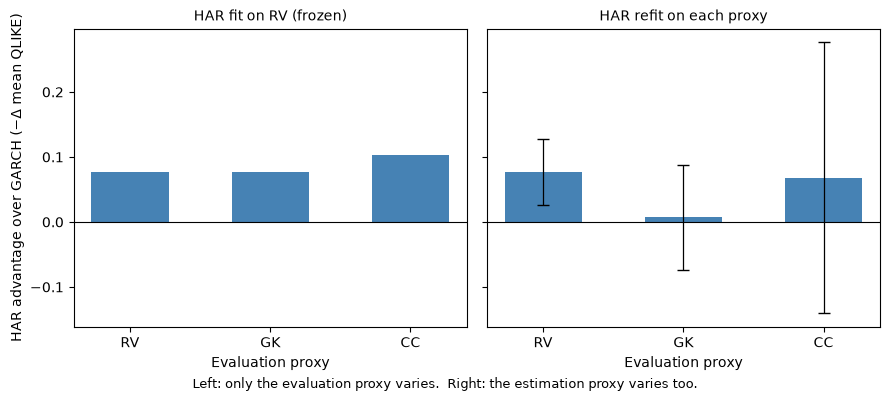

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

R = "../results/"
diffs_primary   = pd.read_csv(R + "diffs_primary.csv", index_col=[0, 1])
frozen_forecast = pd.read_csv(R + "frozen_forecast.csv", index_col=0)

NAMES = ["Realized variance", "Range (GK)", "Close-to-close"]
labels = ["RV", "GK", "CC"]

matched = diffs_primary.xs("HAR − GARCH", level="Comparison").reindex(NAMES)
frozen_gaps  = -frozen_forecast["HAR − GARCH"].reindex(NAMES).values
matched_gaps = -matched["Δ loss"].values
matched_se   =  matched["NW s.e."].values

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)

panels = [
    (frozen_gaps,  None,       "HAR fit on RV (frozen)"),
    (matched_gaps, matched_se, "HAR refit on each proxy"),
]

for a, (vals, err, title) in zip(ax, panels):
    a.bar(labels, vals, yerr=err, color="steelblue", width=0.55,
          capsize=4, error_kw={"lw": 0.9})
    a.axhline(0, color="k", lw=0.8)
    a.set_title(title, fontsize=10)
    a.set_xlabel("Evaluation proxy")

ax[0].set_ylabel("HAR advantage over GARCH (−Δ mean QLIKE)")
fig.suptitle("Left: only the evaluation proxy varies.  "
             "Right: the estimation proxy varies too.", fontsize=9, y=0.02)

plt.tight_layout()
plt.savefig("../figures/two_channels.png", dpi=150, bbox_inches="tight")
plt.show()

HAR's advantage over GARCH in mean QLIKE, by evaluation proxy. On the left the forecast is held fixed (HAR fit on realized variance), so only the grading changes: the advantage is essentially identical under RV and GK (0.0770 vs 0.0774) and larger under CC, reflecting that proxy's greater dispersion rather than any reordering. On the right HAR is refit on each proxy, and the advantage nearly vanishes under GK. The tenfold collapse is therefore an estimation effect, not an evaluation effect. No pairwise difference in either panel is significant.